### using materials projects pymatgen library to plot phase diagrams

In [1]:
from mp_api.client import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter
from pymatgen.core import Element
from pymatgen.entries.mixing_scheme import MaterialsProjectDFTMixingScheme
from pymatgen.entries.compatibility import MaterialsProject2020Compatibility

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_materals_project_data(elements, api_key=API_KEY):
    with MPRester(api_key) as m:
        entries = m.get_entries_in_chemsys(elements, inc_structure=False, additional_criteria={"thermo_types": ["GGA_GGA+U", "R2SCAN"]})
    return entries

# elements = ["C", "Si", "Ni"]
elements = ["Ge", "Si", "Ni"]
entries = get_materals_project_data(elements)

# 1. Initialize the compatibility scheme
# This handles the GGA/GGA+U mixing and elemental corrections
compat = MaterialsProject2020Compatibility()

# 2. Process your raw entries
# This will update the .energy property of each entry with the corrected value
# It also filters out entries that are incompatible with the scheme
processed_entries = compat.process_entries(entries)

# 3. Build the diagram with corrected data
pd_obj = PhaseDiagram(processed_entries)

# 4. Plot the Phase Diagram
plotter = PDPlotter(pd_obj, show_unstable=0.1) # show_unstable is the energy cutoff in eV/atom
plotter.show()

c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\mp_api\client\mprester.py:541: UserWarning: The `inc_structure` argument is deprecated as final structures are always included in all returned ComputedStructureEntry objects.
  warnings.warn(
Retrieving ThermoDoc documents: 100%|██████████| 140/140 [00:00<?, ?it/s]
c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\pymatgen\entries\compatibility.py:629: UserWarning: Failed to guess oxidation states for Entry mp-2291-GGA (Si2Ni). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\pymatgen\entries\compatibility.py:629: UserWarning: Failed to guess oxidation states for Entry mp-29900-GGA (NiGe2). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjust

## manually plot the data to change the design and layout

In [3]:
def get_plottable_pd_data(pd_obj, vertex_order=None):
    """
    Correctly extracts x, y coordinates and stable tie-lines.
    """
    # 1. Setup Elements
    if vertex_order:
        elements = [Element(str(e)) for e in vertex_order]
    else:
        elements = pd_obj.elements
    
    dim = len(elements)

    def calculate_coords(comp):
        if dim == 3:
            # Top (A), Bottom-Left (B), Bottom-Right (C)
            cA = comp.get_atomic_fraction(elements[0])
            cB = comp.get_atomic_fraction(elements[1])
            cC = comp.get_atomic_fraction(elements[2])
            x = cC + 0.5 * cA
            y = cA * (np.sqrt(3) / 2)
            return (float(x), float(y))
        elif dim == 2:
            return (float(comp.get_atomic_fraction(elements[1])), 0.0)
        return (0.0, 0.0)

    # 2. Extract Entry Data for Scatter Plot
    data_rows = []
    for entry in pd_obj.all_entries:
        x, y = calculate_coords(entry.composition)
        e_hull = pd_obj.get_e_above_hull(entry)
        data_rows.append({
            "formula": entry.composition.reduced_formula,
            "x": x, "y": y,
            "e_above_hull": e_hull,
            "is_stable": e_hull <= 1e-7
        })
    df = pd.DataFrame(data_rows)

    # 3. FIX: Extract Tie-Lines using qhull_entries
    tie_lines = []
    # qhull_entries are the only ones used in the facets indices
    q_entries = pd_obj.qhull_entries
    
    for facet in pd_obj.facets:
        for i in range(len(facet)):
            # Create a line between adjacent vertices of the facet
            p1_idx = facet[i]
            p2_idx = facet[(i + 1) % len(facet)]
            
            coord1 = calculate_coords(q_entries[p1_idx].composition)
            coord2 = calculate_coords(q_entries[p2_idx].composition)
            
            # Avoid adding zero-length lines (points)
            if coord1 != coord2:
                # Use a set or sorted tuple to avoid duplicate lines if desired
                tie_lines.append((coord1, coord2))

    return df, tie_lines, [el.symbol for el in elements]

In [4]:
from pymatgen.entries.computed_entries import GibbsComputedStructureEntry

def get_temp_corrected_pd(entries, temp_k):
    """
    Converts a collection of entries to Gibbs Free Energy entries.
    Pass the WHOLE list so the model can find the elemental 'anchors'.
    """
    try:
        # Instead of a loop, pass the entire list 'entries'
        # The function groups them by composition and calculates G(T)
        gibbs_entries = GibbsComputedStructureEntry.from_entries(entries, temp_k)
    except Exception as e:
        print(f"Correction failed: {e}")
        return PhaseDiagram(entries), entries
            
    return PhaseDiagram(gibbs_entries), gibbs_entries

In [24]:
# # test temperature correction

# elements = ["C", "Si", "Ni"]
# df, tie_lines, labels = get_plottable_pd_data(pd_obj, vertex_order=elements)
# pd_at_1200k, gibbs_entries = get_temp_corrected_pd(processed_entries, temp_k=1200)
# # df_1200, tie_lines_1200, labels_1200 = get_plottable_pd_data(pd_at_1200k, vertex_order=elements)

# # Pick a specific material, e.g., SiC
# formula_to_check = "SiC"

# # Get 0K energy
# entry_0k = next(e for e in processed_entries if e.composition.reduced_formula == formula_to_check)
# energy_0k = entry_0k.energy_per_atom

# # Get 1200K energy from your gibbs_entries
# entry_1200k = next(e for e in gibbs_entries if e.composition.reduced_formula == formula_to_check)
# energy_1200k = entry_1200k.energy_per_atom

# # 1. Get the Formation Energy at 0K from the original PhaseDiagram
# form_e_0k = pd_obj.get_form_energy_per_atom(entry_0k)

# # 2. Get the Formation Energy at 1200K from the new PhaseDiagram
# form_e_1200k = pd_at_1200k.get_form_energy_per_atom(entry_1200k)

# print(f"--- {formula_to_check} Formation Stability ---")
# print(f"Formation Energy (0K):    {form_e_0k:.4f} eV/atom")
# print(f"Formation Energy (1200K): {form_e_1200k:.4f} eV/atom")
# print(f"Thermal Stability Shift:  {abs(form_e_0k - form_e_1200k):.4f} eV/atom")

     formula         x         y  e_above_hull is_stable              name
0         Ge  0.500000  0.866025           0.0      True              $Ge$
1         Ni  1.000000  0.000000           0.0      True              $Ni$
2       NiGe  0.750000  0.433013           0.0      True            $NiGe$
3      Ni3Ge  0.875000  0.216506           0.0      True          $Ni_3Ge$
4     Ni5Ge3  0.840000  0.280000           0.0      True        $Ni_5Ge_3$
5   Ni19Ge12  0.820000  0.330000           0.0      True  $Ni_{19}Ge_{12}$
6         Si  0.000000  0.000000           0.0      True              $Si$
7       SiNi  0.500000  0.000000           0.0      True            $NiSi$
8      SiNi2  0.666667  0.000000           0.0      True          $Ni_2Si$
9      SiNi3  0.750000  0.000000           0.0      True          $Ni_3Si$
10   SiNi6Ge  0.812500  0.108253           0.0      True        $GeNi_6Si$
11     Si2Ni  0.333333  0.000000           0.0      True          $NiSi_2$
12     Si7Ge  0.062500  0

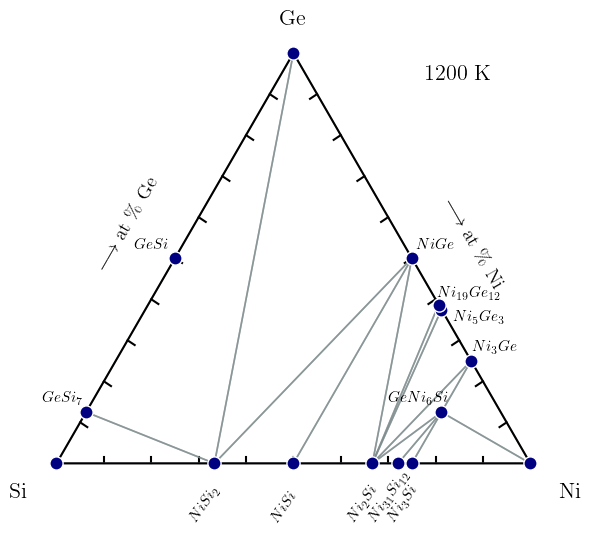

In [ ]:
# Order: Top, Bottom-Left, Bottom-Right
# elements = ["C", "Si", "Ni"]
elements = ["Ge", "Si", "Ni"]
# df, tie_lines, labels = get_plottable_pd_data(pd_obj, vertex_order=elements)
pd_at_1200k, gibbs_entries = get_temp_corrected_pd(processed_entries, temp_k=1200)
df, tie_lines, labels = get_plottable_pd_data(pd_at_1200k, vertex_order=elements)

# 1. Setup
fig, ax = plt.subplots(figsize=(6, 6))
h = np.sqrt(3) / 2  # Height of the triangle

# 2. Draw the Triangle Frame
# Corners: Top (0.5, h), Bottom-Left (0, 0), Bottom-Right (1, 0)
ax.plot([0, 1, 0.5, 0], [0, 0, h, 0], color='black', lw=1.5, zorder=5)

# 3. ADDING AXIS TICKS (0.2, 0.4, 0.6, 0.8 intervals)
tick_len = 0.013
for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    # --- Bottom Edge ---
    ax.plot([i, i], [0, +tick_len], color='black', lw=1.5)
    
    # --- Right Edge ---
    # Coordinate: P = (1,0) + i * (vector from (1,0) to (0.5, h))
    rx = 1 - 0.5 * i
    ry = i * h
    # Vector perpendicular to this edge points roughly (h, 0.5)
    ax.plot([rx, rx - 0.015], [ry, ry - 0.01], color='black', lw=1.5)
    
    # --- Left Edge ---
    lx = 0.5 - 0.5 * i
    ly = h - i * h
    ax.plot([lx, lx + 0.015], [ly, ly - 0.01], color='black', lw=1.5)

# 4. Draw Tie-Lines (using your lines data)
for line in tie_lines:
    (x1, y1), (x2, y2) = line
    ax.plot([x1, x2], [y1, y2], color='#7f8c8d', lw=1.2, alpha=0.7, zorder=2)

# 5. Plot Points (Stable & Unstable)
stable = df[df['is_stable']]
ax.scatter(stable['x'], stable['y'], c="#000080", s=90, edgecolors='white', zorder=10)
# ax.scatter(df[~df['is_stable']]['x'], df[~df['is_stable']]['y'], c='#e74c3c', s=25, alpha=0.3, zorder=3)
# add GeSi
ax.scatter(0.25, 0.4330127018922193, c="#000080", s=90, edgecolors='white', zorder=10)

# 6. CORNER LABELS (Positioned Outside)
# Offset values can be tweaked based on font size
ax.text(0.5, h + 0.05, labels[0], fontsize=16, fontweight='bold', ha='center', va='bottom')
ax.text(-0.06, -0.04, labels[1], fontsize=16, fontweight='bold', ha='right', va='top')
ax.text(1.06, -0.04, labels[2], fontsize=16, fontweight='bold', ha='left', va='top')

# 7. Materials labels
# stable['name'] = ['$C$', '$Ni$', '$Si$', '$SiC$', '$NiSi$', '$Ni_2Si$', '$Ni_3Si$', '$NiSi_2$','$Ni_{31}Si_{12}$']
stable['name'] = ['$Ge$', '$Ni$', '$NiGe$', '$Ni_3Ge$', '$Ni_5Ge_3$', '$Ni_{19}Ge_{12}$', '$Si$', '$NiSi$', '$Ni_2Si$', '$Ni_3Si$',  '$GeNi_6Si$', '$NiSi_2$', '$GeSi_7$','$Ni_{31}Si_{12}$']
new_row = {'formula': 'GeSi', 'x': 0.25, 'y': 0.4330127018922193, 'name': '$GeSi$'}
stable = pd.concat([stable, pd.DataFrame([new_row])], ignore_index=True)

stable.loc[stable['formula'] == 'Ni19Ge12', 'x'] = 0.82
stable.loc[stable['formula'] == 'Ni19Ge12', 'y'] = 0.33
stable.loc[stable['formula'] == 'Ni5Ge3', 'x'] = 0.84
stable.loc[stable['formula'] == 'Ni5Ge3', 'y'] = 0.28
print(stable)
for _, row in stable.iterrows():
    # Ignore the pure element corners for internal labeling to avoid clutter
    if row['formula'] not in elements:
        if row['y'] < 0.01:  # Only for points on the bottom axis
            ax.text(row['x']-0.02, row['y']-0.13, row['name'], ha='center', va='bottom', rotation=55, fontsize=11, fontweight='bold', color='#000000')

        elif row['x'] > 0.5 and row['y'] > 0.2:  # Only for points on the right half and above the bottom axis
            ax.text(row['x']+0.05, row['y']+0.02, row['name'], ha='center', fontsize=11, fontweight='bold', color='#000000')
        elif row['x'] < 0.5 and row['y'] > 0.2:  # Only for points on the left half and above the bottom axis
            ax.text(row['x']-0.05, row['y']+0.02, row['name'], ha='center', fontsize=11, fontweight='bold', color='#000000')
        else:
            ax.text(row['x']-0.05, row['y']+0.02, row['name'], ha='center', fontsize=11, fontweight='bold', color='#000000')

# external labels
ax.text(0.85, 0.8, '1200 K', fontsize=16, fontweight='bold', ha='center', va='bottom')
ax.text(0.15, 0.4, f'$\\longrightarrow$ at \% {labels[0]}', fontsize=14, ha='center', va='bottom', rotation=60)
ax.text(0.88, 0.36, f'$\\longrightarrow$ at \% {labels[2]}', fontsize=14, ha='center', va='bottom', rotation=-60)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
# plt.savefig('../Images/Ge-Ni-Si_phase_diagram.pdf', dpi=300)
plt.show()